# `pyEQL` Tutorial: Solid-liquid-gas Equilibrium

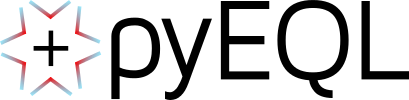

`pyEQL` is an open-source `python` library for solution chemistry calculations and ion properties developed by the [Kingsbury Lab](https://www.kingsburylab.org/) at Princeton University.

[Documentation](https://pyeql.readthedocs.io/en/latest/) | [How to Install](https://pyeql.readthedocs.io/en/latest/installation.html) | [GitHub](https://github.com/KingsburyLab/pyEQL) 

### Select a modeling engine

When creating a `Solution`, you can use the `engine` keyword argument to specify which [Electrolyte Modeling Engine](https://pyeql.readthedocs.io/en/latest/engines.html) you want to use.

- [`ideal`](https://pyeql.readthedocs.io/en/latest/engines.html#the-ideal-engine): Ideal solution model
- [`phreeqc`](https://pyeql.readthedocs.io/en/latest/engines.html#the-phreeqc-engine): Uses `phreeqpython` with `phreeqc.dat`
- [`phreeqc2026`](https://pyeql.readthedocs.io/en/latest/engines.html#the-phreeqc2026-engine): Uses `pyEQL.phreeqc` with `phreeqc.dat (v3.8)` by default
- [`native`](https://pyeql.readthedocs.io/en/latest/engines.html#the-native-engine-default) (default): Uses built-in Pitzer activity model (when available); falls back to other models if not

Below, we demonstrates the soild-liquid-gas equilibrium with the `phreeqc2026` engine.
If you would to use a custom database, please refer to `engines` tutorial. 

### Create solutions with selected engine

In [59]:
from pyEQL import Solution
ENGINE = "phreeqc2026"

### Create a solution without equilibrium

In [60]:
s1 = Solution({"Ca+2": "1 mol/kg", "Cl-": "2 mol/kg"}, engine=ENGINE)
print(
    f"Ca_total = {s1.get_total_amount('Ca', 'M'):~.5f}\n"
    f"Cl_total = {s1.get_total_amount('Cl', 'M'):~.5f}\n"
    f"C_total  = {s1.get_total_amount('C', 'M'):~.5f}"
)

Ca_total = 0.99705 M
Cl_total = 1.99410 M
C_total  = 0.00000 M


### Solid-liquid equilibrium

In [61]:
s1.equilibrate(solids=['Calcite'])
print(
    f"Ca_total = {s1.get_total_amount('Ca', 'M'):~.5f}\n"
    f"Cl_total = {s1.get_total_amount('Cl', 'M'):~.5f}\n"
    f"C_total  = {s1.get_total_amount('C', 'M'):~.5f}"
)

Ca_total = 0.99706 M
Cl_total = 1.99410 M
C_total  = 0.00001 M


### Liquid-gas equilibrium with atmosphere

In [62]:
s2 = Solution({"Ca+2": "1 mol/kg", "Cl-": "2 mol/kg"}, engine=ENGINE)
print(
    f"Ca_total_ori = {s2.get_total_amount('Ca', 'M'):~.5f}\n"
    f"Cl_total_ori = {s2.get_total_amount('Cl', 'M'):~.5f}\n"
    f"O_total_ori = {s2.get_total_amount('O', 'M'):~.5f}\n"
    f"C_total_ori  = {s2.get_total_amount('C', 'M'):~.5f}\n"
)
s2.equilibrate(atmosphere=True)
print(
    f"Ca_total = {s2.get_total_amount('Ca', 'M'):~.5f}\n"
    f"Cl_total = {s2.get_total_amount('Cl', 'M'):~.5f}\n"
    f"O_total = {s2.get_total_amount('O', 'M'):~.5f}\n"     # O2 in the atmosphere
    f"C_total  = {s2.get_total_amount('C', 'M'):~.5f}"      # CO2 in the atmosphere
)

Ca_total_ori = 0.99705 M
Cl_total_ori = 1.99410 M
O_total_ori = 55.34458 M
C_total_ori  = 0.00000 M

Ca_total = 0.99705 M
Cl_total = 1.99410 M
O_total = 55.34488 M
C_total  = 0.00002 M


### Liquid-gas equilibrium with self-defined gas

In [63]:
s3 = Solution({"Ca+2": "1 mol/kg", "Cl-": "2 mol/kg"}, engine=ENGINE)
s3.equilibrate(gases={"CO2": -2}) # in log units
print(
    f"Ca_total = {s3.get_total_amount('Ca', 'M'):~.5f}\n"
    f"Cl_total = {s3.get_total_amount('Cl', 'M'):~.5f}\n"
    f"C_total  = {s3.get_total_amount('C', 'M'):~.5f}"
)

Ca_total = 0.99705 M
Cl_total = 1.99410 M
C_total  = 0.00024 M


### Solid-liquid-gas equilibrium

In [64]:
s4 = Solution({"Ca+2": "1 mol/kg", "Cl-": "2 mol/kg"}, engine=ENGINE)
s4.equilibrate(solids=['Alunite'])
s4.equilibrate(atmosphere=True)
print(
    f"Ca_total = {s4.get_total_amount('Ca', 'M'):~.5f}\n"
    f"Cl_total = {s4.get_total_amount('Cl', 'M'):~.5f}\n"
    f"C_total  = {s4.get_total_amount('C', 'M'):~.5f}"
)

Ca_total = 0.99705 M
Cl_total = 1.99410 M
C_total  = 0.00002 M
